# AutoHF Crash Course
---------------------

In this tutorial, we will cover the basics of using AutoHF for the
purpose of generating trial wavefunctions for SAFIRE.

🛠️ To cover:

- providing a Hamiltonian
    - pinning fields!!
- characterizing the HF SD
    - charge and spin densities
    - spin-spin correlation
- using sufficient parallel trials.
- choosing the ansatz
- choosing the optimization method.

## Software Prelimiaries
------------------------

While AutoHF is a stand alone tool with it's own input format for Hamiltonians.
However, it is able to convert SAFIRE format hamiltonians to it's own internal format very easily.
In this tutorial, we will exclusively use afqmctools to build Hamiltonians,
then use the SAFIRE to AutoHF converter to provide AutoHF with the desired Hamiltonian.

## ▶️ Run the cell below to setup the tutorial
----------------------------------------------


In [ ]:
%load_ext autoreload
%autoreload
from pathlib import Path
# simple setup
from tutorial_utils import run_afqmc, get_scratch_dir

home = Path.home()
scratch_dir = get_scratch_dir("07_hubbard_model_autohf",home / ".scratch")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Set up the model
-------------------

In this tutorial, we will perform Hatree-Fock calculations using AutoHF for the Hubbard model on
a 4x4 lattice.
The Hamiltonian is given by,
$$
\hat{H} = -t \sum_{\langle i,j\rangle} \hat{c}^\dagger_i \hat{c}_j + U \sum_{i} \hat{n}^{\uparrow}_i \hat{n}^{\downarrow}_i,
$$
where $i,j$ are lattice site indices, angle brackets indicate nearest-neighbors,
$\hat{c}^\dagger_i$/$\hat{c}_i$ are electronic creation/anihilation operators,
and $\hat{n}^{\sigma}_i$ are spin-resolved number operators corresponding to site $i$.


computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


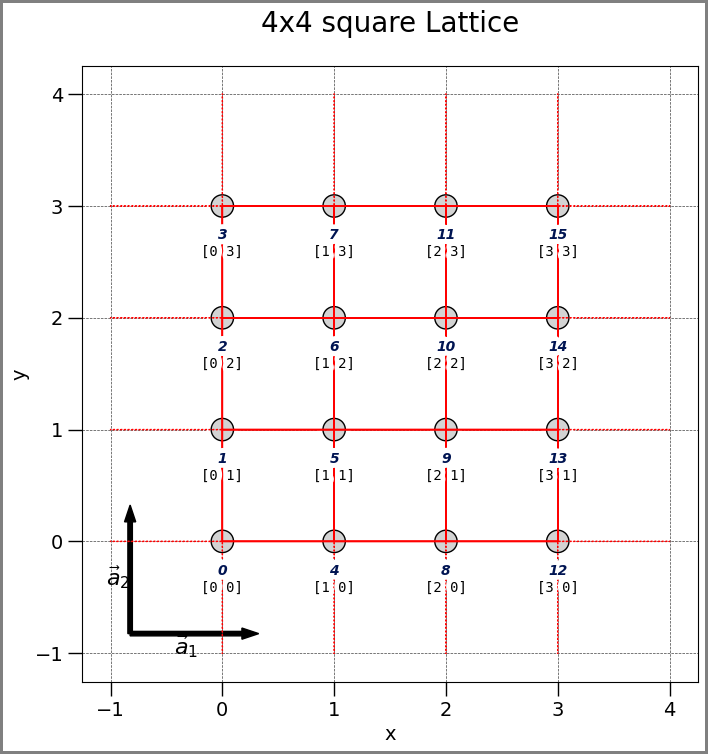

running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((4.0,))
Building Hubbard U term with U=4.0
Building onsite hubbard with positive U values: 4.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


In [ ]:
from afqmctools.hamiltonian.model.director import HamiltonianDirector
import afqmctools.utils.io as io
from afqmctools.systems.lattice import get_lattice
import afqmctools.utils.visualize as vis

lattice_params = dict(
    L1 = 4,
    L2 = 4,
    boundary1 = 'PBC',
    boundary2 = 'PBC',
)

lattice = get_lattice(
    params=lattice_params
)

vis.plot_lattice(lattice)

# Step 2. define Hamiltonian parameters
hamiltonian_params = {
    'hamiltonian' : {
        "t" : 1.0,  # note: we could omit this, nearest-neighbor hoping with t=1 is included by default
        "U" : 4.0
    }
}

# Step 3.b. build the lattice model Ha
hamiltonian = HamiltonianDirector(
    lattice=lattice,
    source=hamiltonian_params
).build()


We now have a "standard" Hubbard model with nearest-neighbor hopping and onsite U in the `hamiltonian` object.

## Setting up a calculation in AutoHF
-------------------------------------

AutoHF requires only two inputs.

1. a Hamiltonian in the AutoHF format
2. Python dictionary containing settings

### 1. Getting a Hamiltonian in AutoHF
--------------------------------------

We can easily convert afqmctools Hamiltonians to the AutoHF format using,

```python
from autohf import AutoHFHamiltonian

hamiltonian_autohf=AutoHFHamiltonian(source=hamiltonian_safire)
```

where `hamiltonian_safire` is a Hamiltonian generated by afqmctools, and
`hamiltonian_autohf` is the same Hamiltonian in the AutoHF format.

### 2. AutoHF settings dictionary
---------------------------------

AutoHF is controlled via a Python dictionary containing various keyword arguments.
Think of this as an input file.
Below is a sample settings dictionary with most common settings exposed.

```python
hf_settings = dict(
    ansatz = 'SD',
    steps = 100,
    nelec = (5,5),
    batch_size = 30,
    seed = 42,
    measure_spin = True,
    noncollinear = False,
    verbose = False,
    riemannian = False
)
```

Covering all of the settings is beyond the scope of this tutorial; however,
we will focus on a few key settings which are as follows.

- `ansatz`
- `steps`
- `batch_size`


When you run AutoHF, it will echo the settings. See sample output below.

```log
    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings =====

        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                     SD
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                                       42
        eta                                                       0.1
        steps                                                     100
        batch_size                                                100
        plot                                                    False
        verbose                                                 False
        output                                                   None
        dump_batch                                              False
        measure_spin                                             True
        random_initial_phi0                                     False
        state0_scale                                             0.01
```

## ▶️ Your Turn: Trying running AutoHF for the 4x4 Hubbard Model
----------------------------------------------------------------

Complete the labelled line of code and run the cell below.

In [ ]:
from autohf import lattice_hf,AutoHFHamiltonian
from afqmctools.inputs.from_autohf import autohf_to_afqmc

# "hamiltonian" contains the afqmctools format Hamiltonian
hamiltonian_autohf = AutoHFHamiltonian(hamiltonian) # Your Turn: convert to the autoHF format

# define settings
hf_settings = dict(
    ansatz = 'SD',
    steps = 100,
    nelec = (5,5),
    batch_size = 30,
    seed = 42,
    measure_spin = True,
    random_initial_phi0 = False,
    noncollinear = True,
    verbose = False
)

results = lattice_hf(
    hamiltonian=hamiltonian_autohf,
    settings=hf_settings
)



Reading hopping from spin sector 0
Reading hopping from spin sector 1
Added unique T terms: [array([-1.]), array([-1.])]
Added unique U terms: [4.]

    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        noncollinear                                             True
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                     SD
        opt_method                                              lbfgs
        riemannian                                              False
        seed                                                       42
        eta                                                       0.1
        steps                               

/mnt/home/beskridge/software/AutoHF_dev/autohf/solver.py:911: ComplexWarning: Casting complex values to real discards the imaginary part
  state0_ref[i, 0:x, 0:y] = p[:, :]


Initial Energy: [5.56765257 4.02987452 5.84943392 6.44181276 6.34245767 8.33574927
 7.66407896 7.18725906 6.86369521 4.95596946 7.07704906 6.42806738
 5.71827116 6.3962971  6.6147098  4.62454872 5.56593982 4.63383018
 5.78557976 5.91083052 6.59698366 5.21017644 3.9093776  6.69985678
 3.22096046 6.47976011 3.56477123 6.78578577 6.13679682 4.97597167]
# iterations: [31 39 26 25 27 19 23 24 32 39 28 36  8 63 33 42 30 50 16 38  4 29 51  9
 40 39 32 16 28 42] frac of possible: [0.31 0.39 0.26 0.25 0.27 0.19 0.23 0.24 0.32 0.39 0.28 0.36 0.08 0.63
 0.33 0.42 0.3  0.5  0.16 0.38 0.04 0.29 0.51 0.09 0.4  0.39 0.32 0.16
 0.28 0.42]
Final energy: -17.7499999549238 [-17.74999841 -17.74999992 -17.74993214 -17.73976625 -17.74547584
   5.85459401 -17.74527564 -17.73693157 -17.74510888 -17.74930487
 -17.6728384  -17.73440715  -4.97150664 -17.74999758 -17.73856209
 -17.74998253 -17.68104844 -17.74999993 -17.74434036 -17.74999806
   7.23961883 -17.7396433  -17.74999994 -10.94707985 -17.74999995
 -17.74

## ✅ Solution
--------------

You should have completed the line of code as,

```python
# "hamiltonian" contains the afqmctools format Hamiltonian
hamiltonian_autohf = AutoHFHamiltonian(hamiltonian)
```

You should have gotten a HF energy of -17.7499999549238 $t$ (to within about $1 \times 10^{-8} t$) when you ran AutoHF.

In [ ]:
autohf_to_afqmc

autohf_to_afqmc(
    results,
    output_fname = scratch_dir/"uhf_wfn.h5"
)


## Analyzing the HF Wavefunction
--------------------------------

It is very important to analyze / characterize the HF solution
before using it as a trial wavefunction to ensure that it is the
desired properties.

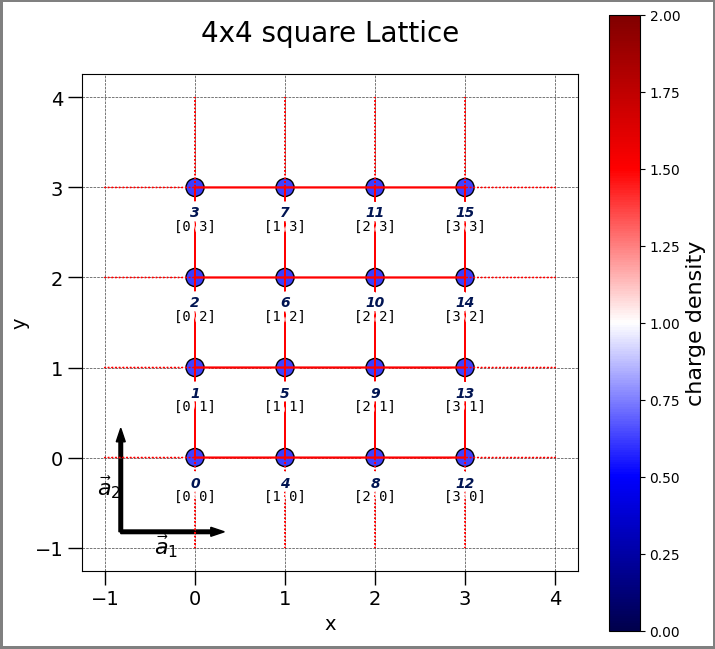

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
# get the density from autohf
state_results, functions = results

makeRDMs = functions['makeRDMs']
state = state_results['state']

rdm = makeRDMs(state)

# get lattice dimensions from the Lattice instance
L = lattice.L

# collinear
#rho_up = rdm[0].diagonal().reshape(*L)
#rho_down = rdm[1].diagonal().reshape(*L)

# noncollinear
M = lattice.N_sites
rho_up = rdm[:M,:M].diagonal().reshape(*L)
rho_down = rdm[M:,M:].diagonal().reshape(*L)

rho_charge = rho_up + rho_down
rho_spin = rho_up - rho_down

vis.plot_lattice(
    lattice,
    density=rho_charge.real,
    density_label="charge density",
    vmin=0.0,
    vmax=2.0
)


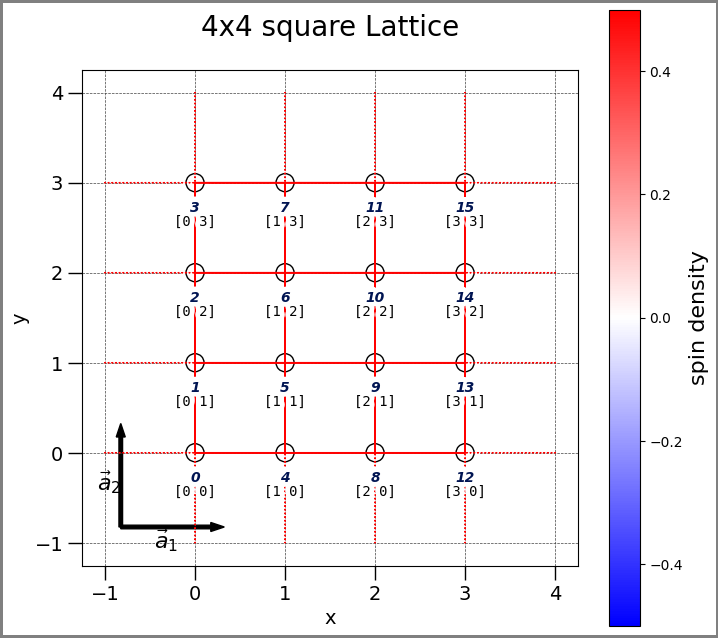

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': '4x4 square Lattice'}, xlabel='x', ylabel='y'>)

In [ ]:
from afqmctools.observables.spin import local_spin

vis.plot_lattice(
    lattice,
    density=rho_spin,
    density_label="spin density",
    cmap="bwr",
    vmin=-0.5,
    vmax=0.5
)
